<a href="https://colab.research.google.com/github/maxgov2703/data-cleaning-eda/blob/main/notebooks/data_cleaning_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
from src.data_cleaning import clean_data
# применяем функцию очистки
df_cleaned = clean_data(df)

df_cleaned.head()

ModuleNotFoundError: No module named 'src'

In [ ]:
# проверка пропусков
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
import os
os.makedirs("plots", exist_ok=True)

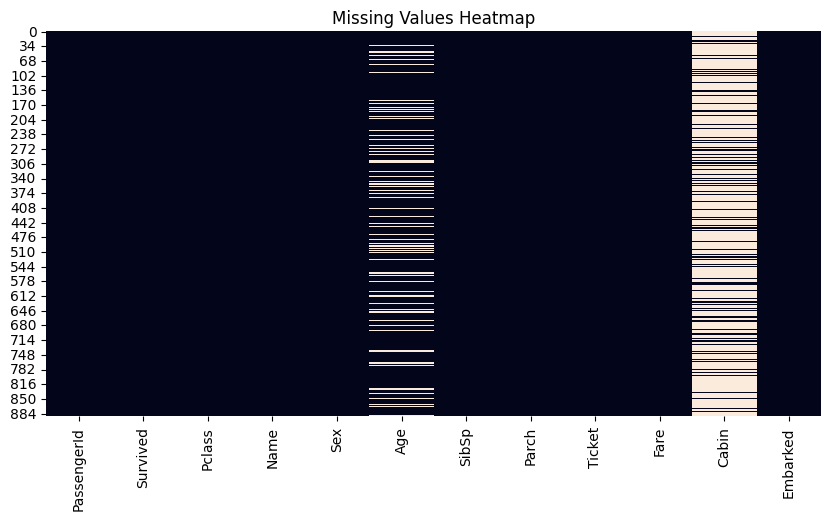

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.savefig("plots/missing_values_heatmap.png")

plt.show()

Cabin слишком много пропусков следовательно удаляем столбец  

Age  важный признак следовательно заполняем медианой  

Embarked  всего 2 пропуска следовательно заполняем модой

In [ ]:
# удаляем столбец Cabin (слишком много пропусков)
df = df.drop(columns=["Cabin"])

# заполняем возраст медианой
df["Age"] = df["Age"].fillna(df["Age"].median())

# заполняем Embarked самым частым значением
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# проверка на дубликаты
df.duplicated().sum()

np.int64(0)

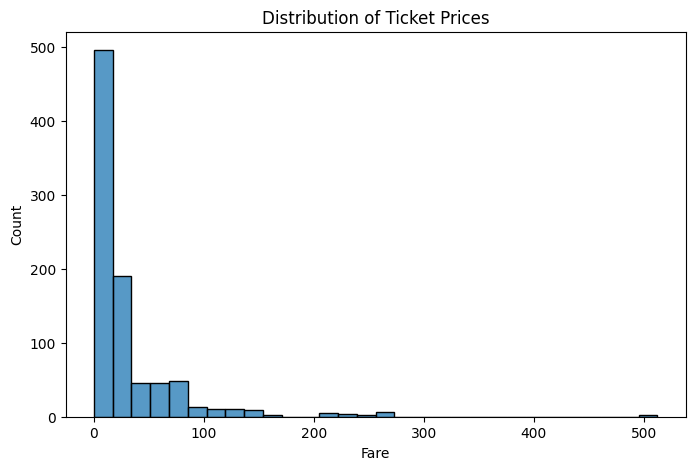

In [ ]:
# распределение стоимости билетов
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30)

plt.title("Distribution of Ticket Prices")

plt.savefig("plots/fare_distribution.png")

plt.show()

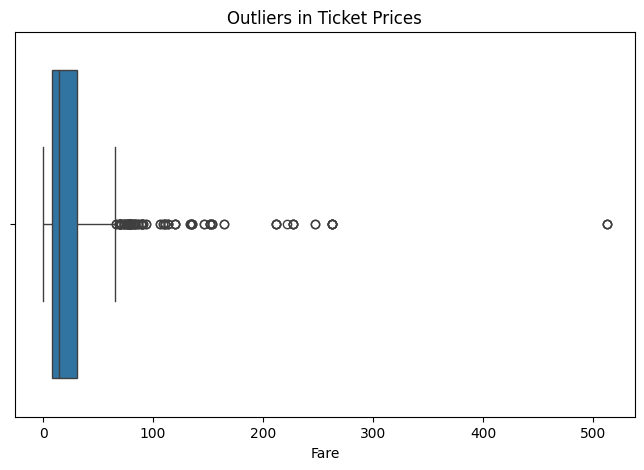

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Outliers in Ticket Prices")

plt.savefig("plots/fare_outliers_boxplot.png")

plt.show()

Анализ выбросов

Переменная «Стоимость проезда» содержит несколько высоких значений.
Эти значения соответствуют билетам первого класса и представляют собой реальные наблюдения.

Поэтому выбросы из набора данных не удаляются

In [ ]:
df.to_csv("titanic_cleaned.csv", index=False)

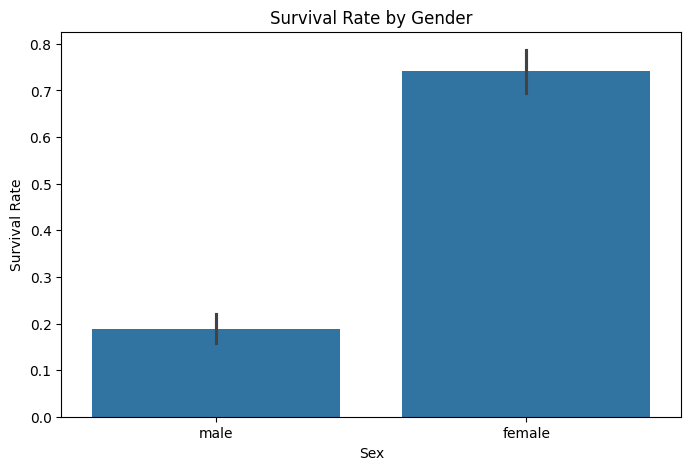

In [ ]:
# выживышие
plt.figure(figsize=(8,5))

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")

plt.savefig("plots/survival_by_gender.png")

plt.show()

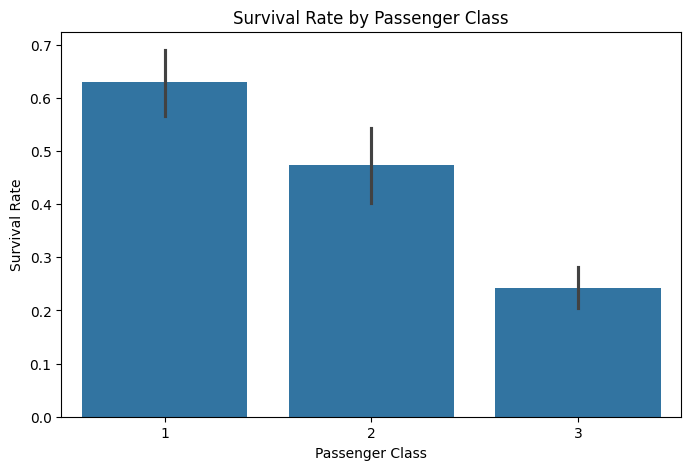

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")

plt.savefig("plots/survival_by_class.png")

plt.show()